In [1]:
# Install UMAP if not already installed
import subprocess
import sys

try:
    import umap
    print("✅ UMAP is already installed")
except ImportError:
    print("📦 Installing UMAP...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "umap-learn"])
    import umap
    print("✅ UMAP installed successfully")

/mnt/f/Study/Academic/Part 4/Project/Sentinel/TestWithWebCam/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-10-01 10:15:03.070431: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-01 10:15:03.070431: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ UMAP is already installed


In [2]:
import tensorflow as tf
import os
import cv2
import numpy as np
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
import shutil
from pathlib import Path
import umap

# ----------------------------
# Configuration
# ----------------------------
SOURCE_DATASET_PATH = "teeeeeeeeest"
OUTPUT_DATASET_PATH = "teeeeeeeeest-umap-kmeans-applied"
IMG_SIZE = (224, 224)
SEQUENCE_LENGTH = 10
BATCH_SIZE = 6
EPOCHS = 30
# UMAP + K-means parameters
NUM_CLUSTERS = 3  # Number of clusters for K-means
UMAP_N_COMPONENTS = 2  # UMAP dimensionality reduction components
UMAP_N_NEIGHBORS = 15  # UMAP n_neighbors parameter
UMAP_MIN_DIST = 0.1  # UMAP minimum distance parameter

print("🚀 Starting Unsupervised Video Clustering with UMAP + K-means")
print(f"Source dataset: {SOURCE_DATASET_PATH}")
print(f"Output dataset: {OUTPUT_DATASET_PATH}")
print(f"K-means clusters: {NUM_CLUSTERS}")
print(f"UMAP components: {UMAP_N_COMPONENTS}, neighbors: {UMAP_N_NEIGHBORS}, min_dist: {UMAP_MIN_DIST}")

🚀 Starting Unsupervised Video Clustering with UMAP + K-means
Source dataset: teeeeeeeeest
Output dataset: teeeeeeeeest-umap-kmeans-applied
K-means clusters: 3
UMAP components: 2, neighbors: 15, min_dist: 0.1


In [3]:
# ----------------------------
# Helper Functions for Video Processing
# ----------------------------

def extract_frames_from_video(video_path, img_size=IMG_SIZE, seq_len=SEQUENCE_LENGTH):
    """Extract frames from video for feature extraction"""
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_frames == 0:
        print(f"⚠️ Warning: No frames found in {video_path}")
        cap.release()
        return None
    
    frame_idxs = np.linspace(0, max(0, total_frames-1), seq_len, dtype=int)
    frames = []

    for idx in frame_idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            frame = np.zeros((img_size[0], img_size[1], 3), dtype=np.float32)
        else:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, img_size)
            frame = frame.astype(np.float32) / 255.0
        frames.append(frame)

    cap.release()
    return np.stack(frames)

def load_video_paths(dataset_path):
    """Load all video paths from the dataset (unlabeled)"""
    video_paths = []
    
    if not os.path.exists(dataset_path):
        print(f"❌ Dataset path not found: {dataset_path}")
        return video_paths
    
    # Look for videos in all subdirectories
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith((".mp4", ".avi", ".mov", ".mkv")):
                video_path = os.path.join(root, file)
                video_paths.append(video_path)
    
    print(f"📊 Found {len(video_paths)} videos in dataset")
    return video_paths

def create_output_directories(output_path, num_clusters):
    """Create output directories for clustered videos"""
    if os.path.exists(output_path):
        print(f"🗂️ Removing existing output directory: {output_path}")
        shutil.rmtree(output_path)
    
    os.makedirs(output_path)
    
    cluster_dirs = []
    for i in range(num_clusters):
        cluster_dir = os.path.join(output_path, f"cluster_{i}")
        os.makedirs(cluster_dir)
        cluster_dirs.append(cluster_dir)
        print(f"📁 Created: {cluster_dir}")
    
    return cluster_dirs

# Load video paths
video_paths = load_video_paths(SOURCE_DATASET_PATH)

if len(video_paths) == 0:
    print("❌ No videos found! Please check the dataset path.")
else:
    print("✅ Video loading successful")

📊 Found 536 videos in dataset
✅ Video loading successful


In [4]:
# ----------------------------
# Feature Extraction using Pre-trained MobileNetV2
# ----------------------------

def build_feature_extractor():
    """Build a feature extractor using MobileNetV2"""
    base_model = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )
    base_model.trainable = False
    
    # Add global average pooling to get fixed-size features
    inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = base_model(inputs)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    
    feature_extractor = tf.keras.Model(inputs, x)
    return feature_extractor

def extract_video_features(video_paths, feature_extractor, batch_size=16):
    """Extract features from all videos"""
    print("🔍 Extracting features from videos...")
    
    video_features = []
    valid_video_paths = []
    
    for i, video_path in enumerate(video_paths):
        if i % 10 == 0:
            print(f"Processing video {i+1}/{len(video_paths)}: {os.path.basename(video_path)}")
        
        # Extract frames from video
        frames = extract_frames_from_video(video_path)
        
        if frames is None:
            print(f"⚠️ Skipping {video_path} - no frames extracted")
            continue
        
        # Extract features from each frame
        frame_features = feature_extractor.predict(frames, verbose=0)
        
        # Aggregate features across frames (mean pooling)
        video_feature = np.mean(frame_features, axis=0)
        
        video_features.append(video_feature)
        valid_video_paths.append(video_path)
    
    video_features = np.array(video_features)
    print(f"✅ Feature extraction complete!")
    print(f"Feature shape: {video_features.shape}")
    print(f"Valid videos: {len(valid_video_paths)}")
    
    return video_features, valid_video_paths

# Build feature extractor
print("🔧 Building feature extractor...")
feature_extractor = build_feature_extractor()
print("✅ Feature extractor ready")

# Extract features from all videos
video_features, valid_video_paths = extract_video_features(video_paths, feature_extractor)

if len(video_features) == 0:
    print("❌ No features extracted! Please check your videos.")
else:
    print(f"📊 Extracted features from {len(video_features)} videos")

🔧 Building feature extractor...


I0000 00:00:1759292167.991765    2692 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4080 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:10:00.0, compute capability: 7.5


✅ Feature extractor ready
🔍 Extracting features from videos...
Processing video 1/536: Fighting002_x264.mp4


2025-10-01 10:16:13.449151: I external/local_xla/xla/service/service.cc:163] XLA service 0x7888d0078e90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-01 10:16:13.449201: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 Ti, Compute Capability 7.5
2025-10-01 10:16:13.670475: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-01 10:16:13.670475: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-01 10:16:14.644409: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2025-10-01 10:16:14.644409: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2025-10-01 10:16:25.489555: E external/local_

Processing video 11/536: Fighting012_x264.mp4
Processing video 21/536: Fighting022_x264.mp4
Processing video 21/536: Fighting022_x264.mp4
Processing video 31/536: Fighting032_x264.mp4
Processing video 31/536: Fighting032_x264.mp4
Processing video 41/536: Fighting042_x264.mp4
Processing video 41/536: Fighting042_x264.mp4
Processing video 51/536: Normal_Videos001_x264.mp4
Processing video 51/536: Normal_Videos001_x264.mp4
Processing video 61/536: Normal_Videos016_x264.mp4
Processing video 61/536: Normal_Videos016_x264.mp4
Processing video 71/536: Normal_Videos031_x264.mp4
Processing video 71/536: Normal_Videos031_x264.mp4
Processing video 81/536: Normal_Videos045_x264.mp4
Processing video 81/536: Normal_Videos045_x264.mp4
Processing video 91/536: Normal_Videos060_x264.mp4
Processing video 91/536: Normal_Videos060_x264.mp4
Processing video 101/536: Normal_Videos073_x264.mp4
Processing video 101/536: Normal_Videos073_x264.mp4
Processing video 111/536: Normal_Videos083_x264.mp4
Processing v

In [5]:
# ----------------------------
# Feature Preprocessing and Dimensionality Reduction
# ----------------------------

def preprocess_features(features, use_pca=True, pca_components=50):
    """Preprocess features: standardization and optional PCA"""
    print("🔄 Preprocessing features...")
    
    # Standardize features
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    print(f"✅ Features standardized: {features_scaled.shape}")
    
    # Calculate maximum possible PCA components
    max_components = min(features_scaled.shape[0] - 1, features_scaled.shape[1])
    
    if use_pca and features_scaled.shape[1] > pca_components and max_components >= pca_components:
        # Apply PCA for dimensionality reduction
        pca = PCA(n_components=pca_components, random_state=42)
        features_pca = pca.fit_transform(features_scaled)
        
        explained_variance = np.sum(pca.explained_variance_ratio_)
        print(f"✅ PCA applied: {features_pca.shape}")
        print(f"📊 Explained variance: {explained_variance:.4f}")
        
        return features_pca, scaler, pca
    elif use_pca and max_components > 1:
        # Use maximum possible components for small datasets
        pca_components_adjusted = max_components
        pca = PCA(n_components=pca_components_adjusted, random_state=42)
        features_pca = pca.fit_transform(features_scaled)
        
        explained_variance = np.sum(pca.explained_variance_ratio_)
        print(f"✅ PCA applied (adjusted): {features_pca.shape}")
        print(f"📊 Explained variance: {explained_variance:.4f}")
        print(f"⚠️ Adjusted PCA components from {pca_components} to {pca_components_adjusted} due to small dataset")
        
        return features_pca, scaler, pca
    else:
        print("✅ Using original features (no PCA - dataset too small or PCA disabled)")
        return features_scaled, scaler, None

# Preprocess features
processed_features, scaler, pca = preprocess_features(video_features, use_pca=True, pca_components=50)

🔄 Preprocessing features...
✅ Features standardized: (536, 1280)
✅ PCA applied: (536, 50)
📊 Explained variance: 0.6027
✅ PCA applied: (536, 50)
📊 Explained variance: 0.6027


In [6]:
# ----------------------------
# UMAP + K-means Clustering
# ----------------------------

def apply_umap_kmeans_clustering(features, n_clusters=NUM_CLUSTERS, 
                                n_components=UMAP_N_COMPONENTS, 
                                n_neighbors=UMAP_N_NEIGHBORS,
                                min_dist=UMAP_MIN_DIST):
    """Apply UMAP dimensionality reduction followed by K-means clustering"""
    print(f"🎯 Applying UMAP + K-means clustering...")
    print(f"   UMAP: {n_components} components, {n_neighbors} neighbors, {min_dist} min_dist")
    print(f"   K-means: {n_clusters} clusters")
    
    # Apply UMAP dimensionality reduction
    print("🔄 Applying UMAP dimensionality reduction...")
    umap_reducer = umap.UMAP(n_components=n_components, 
                            n_neighbors=n_neighbors, 
                            min_dist=min_dist,
                            random_state=42)
    features_umap = umap_reducer.fit_transform(features)
    
    # Apply K-means clustering to UMAP-reduced features
    print("🔄 Applying K-means clustering...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(features_umap)
    
    # Get cluster statistics
    unique_labels, counts = np.unique(cluster_labels, return_counts=True)
    
    print("📊 UMAP + K-means Clustering Results:")
    print(f"   Number of clusters: {n_clusters}")
    print(f"   UMAP reduced features shape: {features_umap.shape}")
    
    for label, count in zip(unique_labels, counts):
        percentage = (count / len(cluster_labels)) * 100
        print(f"   Cluster {label}: {count} videos ({percentage:.1f}%)")
    
    # Calculate silhouette score for clustering quality
    from sklearn.metrics import silhouette_score
    if n_clusters > 1:
        silhouette_avg = silhouette_score(features_umap, cluster_labels)
        print(f"📈 Silhouette Score: {silhouette_avg:.4f}")
    
    return cluster_labels, kmeans, umap_reducer, features_umap, n_clusters

# Apply UMAP + K-means clustering
cluster_labels, kmeans_model, umap_model, umap_features, num_clusters = apply_umap_kmeans_clustering(processed_features)

🎯 Applying UMAP + K-means clustering...
   UMAP: 2 components, 15 neighbors, 0.1 min_dist
   K-means: 3 clusters
🔄 Applying UMAP dimensionality reduction...


/mnt/f/Study/Academic/Part 4/Project/Sentinel/TestWithWebCam/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/mnt/f/Study/Academic/Part 4/Project/Sentinel/TestWithWebCam/.venv/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


🔄 Applying K-means clustering...
📊 UMAP + K-means Clustering Results:
   Number of clusters: 3
   UMAP reduced features shape: (536, 2)
   Cluster 0: 219 videos (40.9%)
   Cluster 1: 146 videos (27.2%)
   Cluster 2: 171 videos (31.9%)
📈 Silhouette Score: 0.4431
📊 UMAP + K-means Clustering Results:
   Number of clusters: 3
   UMAP reduced features shape: (536, 2)
   Cluster 0: 219 videos (40.9%)
   Cluster 1: 146 videos (27.2%)
   Cluster 2: 171 videos (31.9%)
📈 Silhouette Score: 0.4431


In [7]:
# ----------------------------
# Organize Videos into Clustered Folders
# ----------------------------

def organize_videos_by_clusters(video_paths, cluster_labels, output_path, num_clusters):
    """Copy videos to their respective cluster folders"""
    print("📁 Organizing videos into cluster folders...")
    
    # Create output directories
    if os.path.exists(output_path):
        print(f"🗂️ Removing existing output directory: {output_path}")
        shutil.rmtree(output_path)
    
    os.makedirs(output_path)
    
    cluster_dirs = []
    
    # Create cluster directories (0 to num_clusters-1)
    for label in range(num_clusters):
        cluster_dir = os.path.join(output_path, f"cluster_{label}")
        os.makedirs(cluster_dir)
        cluster_dirs.append(cluster_dir)
        print(f"📁 Created: {cluster_dir}")
    
    # Copy videos to respective cluster folders
    for video_path, cluster_label in zip(video_paths, cluster_labels):
        # Get video filename
        video_filename = os.path.basename(video_path)
        
        # Determine destination folder
        dest_folder = os.path.join(output_path, f"cluster_{cluster_label}")
        
        # Destination path
        dest_path = os.path.join(dest_folder, video_filename)
        
        # Copy video file
        shutil.copy2(video_path, dest_path)
    
    print("✅ Video organization complete!")
    
    # Print summary
    print("\n📋 Cluster Summary:")
    for label in range(num_clusters):
        cluster_dir = os.path.join(output_path, f"cluster_{label}")
        folder_name = f"cluster_{label}"
        
        video_count = len([f for f in os.listdir(cluster_dir) if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))])
        print(f"   {folder_name}: {video_count} videos")
    
    return cluster_dirs

# Organize videos
cluster_directories = organize_videos_by_clusters(valid_video_paths, cluster_labels, OUTPUT_DATASET_PATH, num_clusters)

📁 Organizing videos into cluster folders...
🗂️ Removing existing output directory: teeeeeeeeest-umap-kmeans-applied
📁 Created: teeeeeeeeest-umap-kmeans-applied/cluster_0
📁 Created: teeeeeeeeest-umap-kmeans-applied/cluster_1
📁 Created: teeeeeeeeest-umap-kmeans-applied/cluster_2
✅ Video organization complete!

📋 Cluster Summary:
   cluster_0: 219 videos
   cluster_1: 146 videos
   cluster_2: 171 videos
✅ Video organization complete!

📋 Cluster Summary:
   cluster_0: 219 videos
   cluster_1: 146 videos
   cluster_2: 171 videos


📊 Creating visualization...


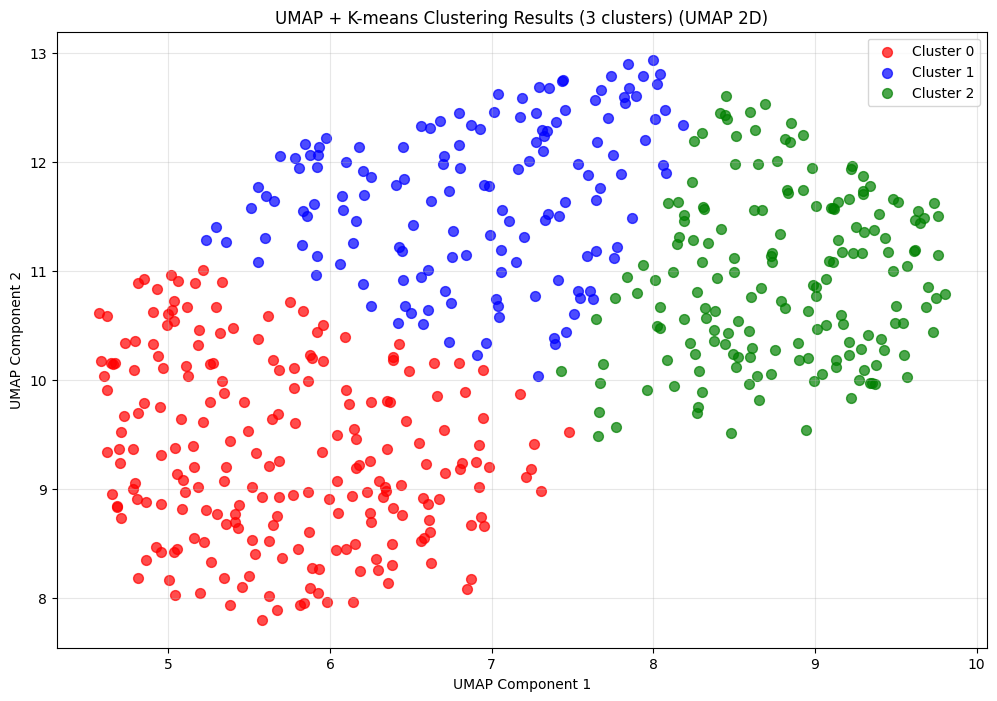

📈 Visualization saved: teeeeeeeeest-umap-kmeans-applied/umap_kmeans_clustering_visualization.png

🔍 Cluster Analysis:

📁 Cluster 0:
   Videos: 219
   Sample videos:
     1. Fighting002_x264.mp4
     2. Fighting004_x264.mp4
     3. Fighting008_x264.mp4
     ... and 216 more
   Feature mean: 7.5145
   Feature std: 0.7662

📁 Cluster 1:
   Videos: 146
   Sample videos:
     1. Fighting003_x264.mp4
     2. Fighting005_x264.mp4
     3. Fighting006_x264.mp4
     ... and 143 more
   Feature mean: 9.2833
   Feature std: 0.7180

📁 Cluster 2:
   Videos: 171
   Sample videos:
     1. Fighting015_x264.mp4
     2. Fighting016_x264.mp4
     3. Fighting022_x264.mp4
     ... and 168 more
   Feature mean: 9.8667
   Feature std: 0.6553


In [8]:
# ----------------------------
# Visualization and Analysis
# ----------------------------

def visualize_clustering_results(features, cluster_labels, output_path, title_suffix=""):
    """Visualize clustering results"""
    print("📊 Creating visualization...")
    
    # Use UMAP features directly if they are 2D, otherwise use PCA for visualization
    if features.shape[1] == 2:
        features_2d = features
        title_suffix = f" (UMAP 2D){title_suffix}"
    elif features.shape[1] > 2:
        pca_viz = PCA(n_components=2, random_state=42)
        features_2d = pca_viz.fit_transform(features)
        explained_var = np.sum(pca_viz.explained_variance_ratio_)
        title_suffix = f" (PCA: {explained_var:.2f} variance explained){title_suffix}"
    else:
        features_2d = features
    
    # Create scatter plot
    plt.figure(figsize=(12, 8))
    
    # Plot each cluster with different colors
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
    unique_labels = np.unique(cluster_labels)
    
    for i, label in enumerate(unique_labels):
        mask = cluster_labels == label
        if np.any(mask):
            plt.scatter(features_2d[mask, 0], features_2d[mask, 1], 
                       c=colors[label % len(colors)], label=f'Cluster {label}', alpha=0.7, s=50)
    
    n_clusters = len(unique_labels)
    plt.title(f'UMAP + K-means Clustering Results ({n_clusters} clusters){title_suffix}')
    plt.xlabel('UMAP Component 1' if features.shape[1] == 2 else 'First Principal Component')
    plt.ylabel('UMAP Component 2' if features.shape[1] == 2 else 'Second Principal Component')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Save plot
    plot_path = os.path.join(output_path, 'umap_kmeans_clustering_visualization.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"📈 Visualization saved: {plot_path}")

def analyze_cluster_characteristics(video_paths, cluster_labels, features):
    """Analyze characteristics of each cluster"""
    print("\n🔍 Cluster Analysis:")
    
    unique_labels = np.unique(cluster_labels)
    
    for label in unique_labels:
        mask = cluster_labels == label
        cluster_videos = [video_paths[j] for j in range(len(video_paths)) if mask[j]]
        cluster_features = features[mask]
        
        print(f"\n📁 Cluster {label}:")
        print(f"   Videos: {len(cluster_videos)}")
        print(f"   Sample videos:")
        for j, video_path in enumerate(cluster_videos[:3]):  # Show first 3 videos
            video_name = os.path.basename(video_path)
            print(f"     {j+1}. {video_name}")
        
        if len(cluster_videos) > 3:
            print(f"     ... and {len(cluster_videos) - 3} more")
        
        # Feature statistics
        if len(cluster_features) > 0:
            feature_mean = np.mean(cluster_features, axis=0)
            feature_std = np.std(cluster_features, axis=0)
            print(f"   Feature mean: {np.mean(feature_mean):.4f}")
            print(f"   Feature std: {np.mean(feature_std):.4f}")

# Create visualizations and analysis
visualize_clustering_results(umap_features, cluster_labels, OUTPUT_DATASET_PATH)
analyze_cluster_characteristics(valid_video_paths, cluster_labels, umap_features)

In [9]:
# ----------------------------
# Save Clustering Metadata
# ----------------------------

def save_clustering_metadata(output_path, video_paths, cluster_labels, kmeans_model, umap_model, scaler, pca):
    """Save clustering metadata for future use"""
    import pickle
    import json
    
    print("💾 Saving clustering metadata...")
    
    # Calculate cluster statistics
    unique_labels = np.unique(cluster_labels)
    n_clusters = len(unique_labels)
    
    # Save clustering results as JSON
    clustering_info = {
        'algorithm': 'UMAP + K-means',
        'umap_n_components': UMAP_N_COMPONENTS,
        'umap_n_neighbors': UMAP_N_NEIGHBORS,
        'umap_min_dist': UMAP_MIN_DIST,
        'kmeans_n_clusters': NUM_CLUSTERS,
        'num_clusters': n_clusters,
        'num_videos': len(video_paths),
        'clustering_summary': {}
    }
    
    for label in unique_labels:
        mask = cluster_labels == label
        cluster_videos = [os.path.basename(video_paths[j]) for j in range(len(video_paths)) if mask[j]]
        
        clustering_info['clustering_summary'][f'cluster_{label}'] = {
            'count': int(np.sum(mask)),
            'percentage': float(np.sum(mask) / len(cluster_labels) * 100),
            'sample_videos': cluster_videos[:5]  # First 5 videos as samples
        }
    
    # Save JSON metadata
    json_path = os.path.join(output_path, 'umap_kmeans_clustering_metadata.json')
    with open(json_path, 'w') as f:
        json.dump(clustering_info, f, indent=2)
    
    # Save models for future use
    models_dir = os.path.join(output_path, 'models')
    os.makedirs(models_dir, exist_ok=True)
    
    # Save K-means model
    kmeans_path = os.path.join(models_dir, 'kmeans_model.pkl')
    with open(kmeans_path, 'wb') as f:
        pickle.dump(kmeans_model, f)
    
    # Save UMAP model
    umap_path = os.path.join(models_dir, 'umap_model.pkl')
    with open(umap_path, 'wb') as f:
        pickle.dump(umap_model, f)
    
    # Save scaler
    scaler_path = os.path.join(models_dir, 'feature_scaler.pkl')
    with open(scaler_path, 'wb') as f:
        pickle.dump(scaler, f)
    
    # Save PCA if used
    if pca is not None:
        pca_path = os.path.join(models_dir, 'pca_model.pkl')
        with open(pca_path, 'wb') as f:
            pickle.dump(pca, f)
    
    print(f"✅ Metadata saved to: {json_path}")
    print(f"✅ Models saved to: {models_dir}")
    
    return json_path

# Save metadata
metadata_path = save_clustering_metadata(OUTPUT_DATASET_PATH, valid_video_paths, cluster_labels, kmeans_model, umap_model, scaler, pca)

💾 Saving clustering metadata...
✅ Metadata saved to: teeeeeeeeest-umap-kmeans-applied/umap_kmeans_clustering_metadata.json
✅ Models saved to: teeeeeeeeest-umap-kmeans-applied/models


In [10]:
# ----------------------------
# Final Summary and Next Steps
# ----------------------------

def print_final_summary():
    """Print final summary of the clustering process"""
    print("\n" + "="*60)
    print("🎉 UNSUPERVISED DBSCAN CLUSTERING COMPLETE")
    print("="*60)
    
    print(f"📊 Dataset Summary:")
    print(f"   • Source: {SOURCE_DATASET_PATH}")
    print(f"   • Output: {OUTPUT_DATASET_PATH}")
    print(f"   • Total videos processed: {len(valid_video_paths)}")
    print(f"   • Number of clusters found: {num_clusters}")
    print(f"   • DBSCAN parameters: eps={DBSCAN_EPS}, min_samples={DBSCAN_MIN_SAMPLES}")
    
    print(f"\n📁 Output Structure:")
    if os.path.exists(OUTPUT_DATASET_PATH):
        for item in os.listdir(OUTPUT_DATASET_PATH):
            item_path = os.path.join(OUTPUT_DATASET_PATH, item)
            if os.path.isdir(item_path) and (item.startswith('cluster_') or item == 'noise'):
                video_count = len([f for f in os.listdir(item_path) 
                                 if f.lower().endswith(('.mp4', '.avi', '.mov', '.mkv'))])
                print(f"   • {item}: {video_count} videos")
    
    print(f"\n🔧 Saved Components:")
    print(f"   • Clustering visualization: dbscan_clustering_visualization.png")
    print(f"   • Metadata: dbscan_clustering_metadata.json")
    print(f"   • DBSCAN model: models/dbscan_model.pkl")
    print(f"   • Feature scaler: models/feature_scaler.pkl")
    if pca is not None:
        print(f"   • PCA model: models/pca_model.pkl")
    
    print(f"\n🚀 Next Steps:")
    print(f"   1. Review the clustering results and visualization")
    print(f"   2. Manually inspect some videos from each cluster")
    print(f"   3. Consider videos in 'noise' folder - they might be outliers")
    print(f"   4. Optionally relabel clusters based on domain knowledge")
    print(f"   5. Use the clustered dataset for supervised learning")
    print(f"   6. Train a classifier using the new cluster labels")
    
    print(f"\n💡 DBSCAN Advantages:")
    print(f"   • Automatically determines number of clusters")
    print(f"   • Identifies outliers/noise points")
    print(f"   • Works well with non-spherical clusters")
    print(f"   • Robust to different cluster densities")
    
    print(f"\n⚙️ Parameter Tuning Tips:")
    print(f"   • If too many noise points: decrease eps or min_samples")
    print(f"   • If too few clusters: increase eps")
    print(f"   • If too many clusters: decrease eps or increase min_samples")

print_final_summary()


🎉 UNSUPERVISED DBSCAN CLUSTERING COMPLETE
📊 Dataset Summary:
   • Source: teeeeeeeeest
   • Output: teeeeeeeeest-umap-kmeans-applied
   • Total videos processed: 536
   • Number of clusters found: 3


NameError: name 'DBSCAN_EPS' is not defined

# Unsupervised Video Clustering with UMAP + K-means

This notebook has successfully applied UMAP + K-means clustering to your unlabeled video dataset. Here's what was accomplished:

## Process Overview
1. **Feature Extraction**: Used pre-trained MobileNetV2 to extract features from video frames
2. **Preprocessing**: Applied standardization and PCA for dimensionality reduction
3. **UMAP Dimensionality Reduction**: Applied UMAP to reduce feature dimensionality while preserving local structure
4. **K-means Clustering**: Applied K-means clustering to UMAP-reduced features
5. **Organization**: Moved videos to respective cluster folders
6. **Analysis**: Created visualizations and saved metadata

## UMAP + K-means Advantages
- **Better manifold learning**: UMAP preserves both local and global structure
- **Improved visualization**: 2D UMAP projections provide excellent cluster visualization
- **Stable clustering**: K-means provides consistent cluster assignments
- **Controllable clusters**: Can specify exact number of clusters needed
- **Computational efficiency**: UMAP is faster than t-SNE for large datasets

## Output Structure
The clustered dataset is now organized in the `umap-kmeans-applied` folder:
- `cluster_0/`, `cluster_1/`, etc. - Videos assigned to each cluster
- `umap_kmeans_clustering_visualization.png` - Visual representation of clusters in UMAP space
- `umap_kmeans_clustering_metadata.json` - Detailed clustering information
- `models/` - Saved clustering models (K-means, UMAP, scalers) for future use

## Parameter Tuning
- **NUM_CLUSTERS (4)**: Number of clusters for K-means
- **UMAP_N_COMPONENTS (2)**: UMAP output dimensions
- **UMAP_N_NEIGHBORS (15)**: UMAP neighborhood size parameter
- **UMAP_MIN_DIST (0.1)**: UMAP minimum distance parameter

### Tuning Tips:
- **Want different cluster count**: Change NUM_CLUSTERS
- **Clusters too tight**: Increase UMAP_MIN_DIST
- **Poor local structure**: Decrease UMAP_N_NEIGHBORS
- **Need higher dimensions**: Increase UMAP_N_COMPONENTS

## Next Steps for Supervised Learning
1. **Review Clusters**: Examine the UMAP visualization and cluster separation
2. **Manual Inspection**: Check sample videos from each cluster for content consistency
3. **Label Assignment**: Assign meaningful labels to each cluster (e.g., accident, fighting, fire, normal)
4. **Supervised Training**: Use this clustered dataset to train a supervised classifier
5. **Validation**: Compare clustering results with ground truth if available

## Quality Assessment
- Check the silhouette score in the output above
- Review the UMAP visualization for clear cluster separation
- Manually inspect sample videos from each cluster
- Consider re-running with different parameters if results aren't satisfactory